/tmp/ipython-input-177/1577471633.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


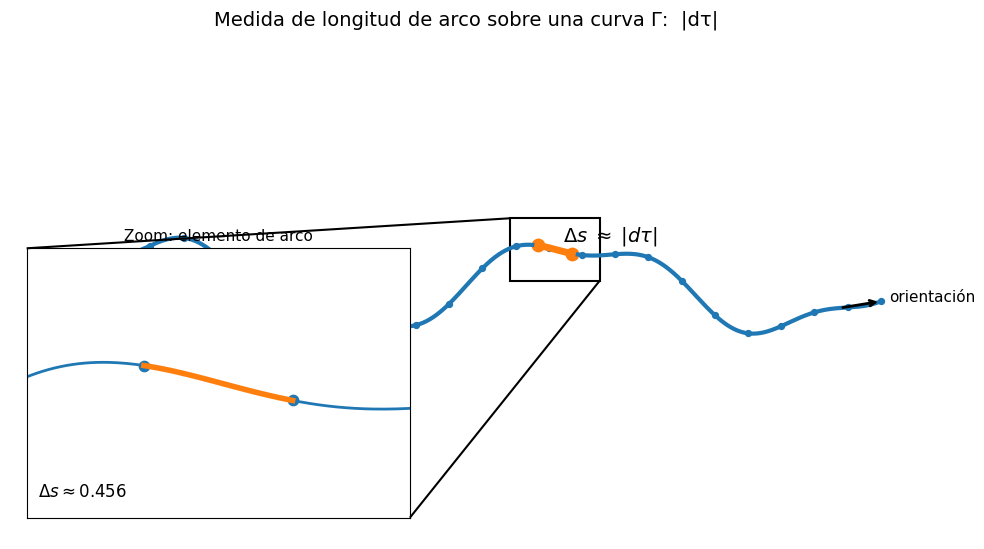

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Ilustración de la medida de longitud de arco |dτ| sobre una curva Γ.

Genera 2 figuras:
  1) Curva Γ con marcas tipo "ticks" y un elemento de arco Δs entre dos puntos.
  2) Un "zoom" (inset) mostrando el pequeño arco y la etiqueta Δs ≈ |dτ|.

Requisitos:
  pip install matplotlib numpy

Uso:
  python arc_length_measure_demo.py
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


def gamma(t: np.ndarray) -> np.ndarray:
    """
    Parametrización suave de una curva plana (tipo 'S' ondulada).
    Devuelve puntos en C como x + i y.
    """
    x = 1.9 * t
    y = 0.55 * np.sin(2.2 * t) + 0.15 * np.sin(6.0 * t)
    return x + 1j * y


def arc_length(z: np.ndarray) -> float:
    """Longitud aproximada por suma de segmentos."""
    dz = np.diff(z)
    return float(np.sum(np.abs(dz)))


def main():
    # Malla para dibujar la curva
    t = np.linspace(-2.8, 2.8, 1200)
    z = gamma(t)
    x, y = z.real, z.imag

    # Elegimos un punto t0 y un pequeño intervalo alrededor para Δs
    t0 = 0.6
    dt = 0.12
    mask = (t >= t0 - dt) & (t <= t0 + dt)
    z_seg = z[mask]
    ds = arc_length(z_seg)  # Δs aproximado

    # Puntos extremos del segmento de arco
    zA = z_seg[0]
    zB = z_seg[-1]

    # Elegimos "ticks" en la curva (muestras espaciadas)
    tick_idx = np.linspace(0, len(t) - 1, 26).astype(int)
    z_ticks = z[tick_idx]

    # Figura principal
    fig, ax = plt.subplots(figsize=(10, 5.6))
    ax.plot(x, y, linewidth=3)
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title("Medida de longitud de arco sobre una curva Γ:  |dτ|", fontsize=14)

    # Dibujar ticks
    ax.scatter(z_ticks.real, z_ticks.imag, s=18)

    # Flecha de orientación (aprox tangente) cerca del final
    # Tomamos dos puntos cercanos al final para una flecha
    z_end1, z_end2 = z[-60], z[-1]
    ax.annotate(
        "",
        xy=(z_end2.real, z_end2.imag),
        xytext=(z_end1.real, z_end1.imag),
        arrowprops=dict(arrowstyle="->", lw=2),
    )
    ax.text(z_end2.real + 0.1, z_end2.imag, "orientación", fontsize=11)

    # Resaltar el pequeño arco (Δs)
    ax.plot(z_seg.real, z_seg.imag, linewidth=5)
    ax.scatter([zA.real, zB.real], [zA.imag, zB.imag], s=80)

    # Etiqueta Δs cerca del segmento
    mid = z_seg[len(z_seg) // 2]
    ax.text(
        mid.real + 0.1,
        mid.imag + 0.12,
        r"$\Delta s \;\approx\; |d\tau|$",
        fontsize=14,
    )

    # Añadir un inset (zoom)
    axins = inset_axes(ax, width="42%", height="55%", loc="lower left", borderpad=1.2)
    axins.plot(x, y, linewidth=2)
    axins.plot(z_seg.real, z_seg.imag, linewidth=4)
    axins.scatter([zA.real, zB.real], [zA.imag, zB.imag], s=55)

    # Ajustar límites del inset alrededor del segmento
    pad = 0.35
    xmin = min(z_seg.real) - pad
    xmax = max(z_seg.real) + pad
    ymin = min(z_seg.imag) - pad
    ymax = max(z_seg.imag) + pad
    axins.set_xlim(xmin, xmax)
    axins.set_ylim(ymin, ymax)
    axins.set_aspect("equal", adjustable="box")
    axins.set_xticks([])
    axins.set_yticks([])
    axins.set_title("Zoom: elemento de arco", fontsize=11)

    # Etiqueta numérica opcional para Δs
    axins.text(
        0.03,
        0.08,
        rf"$\Delta s \approx {ds:.3f}$",
        transform=axins.transAxes,
        fontsize=12,
    )

    # Conectar inset con el área ampliada
    mark_inset(ax, axins, loc1=2, loc2=4, lw=1.5)

    # Limpiar ejes si lo quieres “tipo slide”
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

<>:8: SyntaxWarning: invalid escape sequence '\ '
<>:8: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-1215/1669657287.py:8: SyntaxWarning: invalid escape sequence '\ '
  - Integración sobre Γ \ Γ(t, ε)


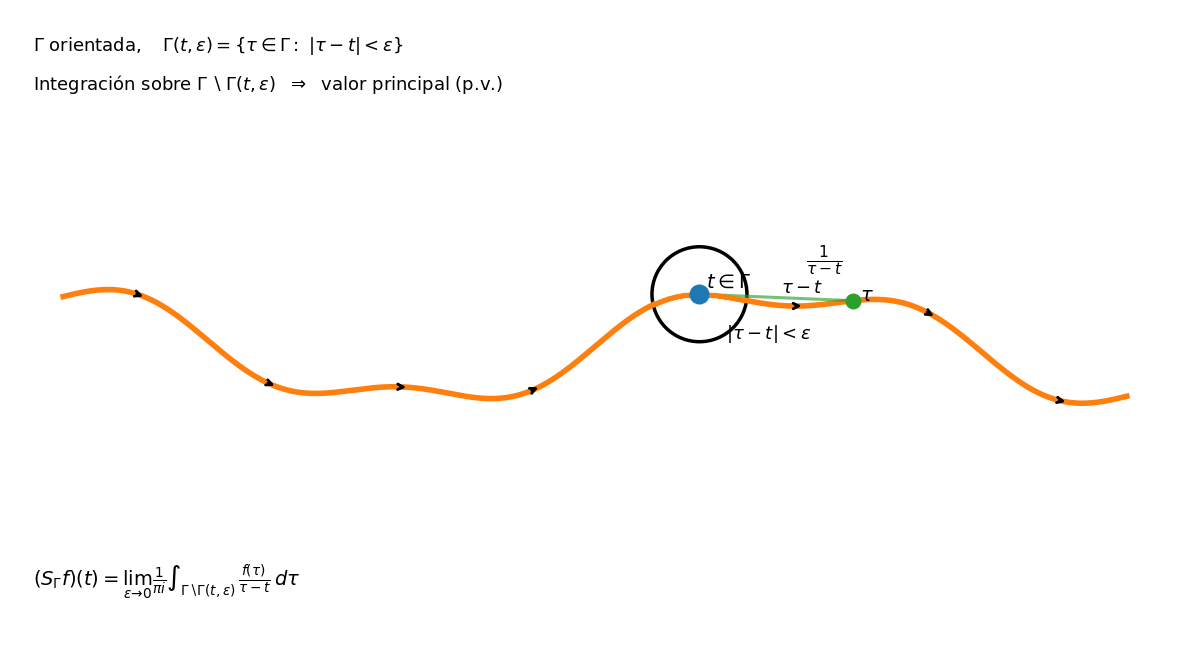

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Dibujo alusivo a la Def. 3.1 (operador integral singular de Cauchy):
- Curva Γ orientada
- Punto t ∈ Γ
- Vecindario excluido Γ(t, ε) = {τ ∈ Γ : |τ - t| < ε}
- Integración sobre Γ \ Γ(t, ε)
- Etiquetas: τ, t, ε, 1/(τ - t), p.v.

Requisitos:
  pip install numpy matplotlib

Uso:
  python draw_cauchy_pv_definition.py
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


def gamma(s: np.ndarray) -> np.ndarray:
    """
    Curva suave en C (estilo 'S' ondulada) para ilustración.
    Devuelve z(s) = x(s) + i y(s)
    """
    x = 2.2 * s
    y = 0.65 * np.sin(1.6 * s) + 0.18 * np.sin(4.6 * s)
    return x + 1j * y


def nearest_index(z: np.ndarray, target: complex) -> int:
    return int(np.argmin(np.abs(z - target)))


def main():
    # Parametrización y puntos de la curva
    s = np.linspace(-2.8, 2.8, 1800)
    z = gamma(s)

    # Elegimos un punto t en la curva (por parámetro s0)
    s0 = 0.55
    t_point = gamma(np.array([s0]))[0]  # complejo
    idx_t = nearest_index(z, t_point)

    # Elegimos epsilon (radio euclidiano en el plano)
    eps = 0.55

    # Determinar el subconjunto excluido: |τ - t| < eps
    dist = np.abs(z - t_point)
    mask_keep = dist >= eps
    mask_cut = dist < eps

    # Para dibujar la integración como dos arcos (dos segmentos separados),
    # detectamos el "corte" alrededor del punto.
    # Tomamos un intervalo alrededor de idx_t para sombrear/mostrar recorte.
    # (Simple: usamos mask_cut directamente.)
    z_keep = z.copy()
    z_keep[~mask_keep] = np.nan + 1j * np.nan

    # Figura
    fig, ax = plt.subplots(figsize=(12, 6.6))

    # Fondo tipo "slide" (cuadriculado suave)
    ax.set_facecolor("white")
    ax.grid(True, linewidth=0.6, alpha=0.25)
    ax.set_aspect("equal", adjustable="datalim")

    # Curva Γ completa (tenue)
    ax.plot(z.real, z.imag, linewidth=3.0, alpha=0.22)

    # Curva de integración Γ \ Γ(t, ε) (resaltada)
    ax.plot(z_keep.real, z_keep.imag, linewidth=4.0)

    # Marcar orientación (flechas a lo largo de la curva)
    # Ponemos flechas en varios puntos (evitando la región cortada)
    arrow_indices = np.linspace(120, len(z) - 120, 8).astype(int)
    for k in arrow_indices:
        if np.isnan(z_keep.real[k]):
            continue
        z1 = z[k]
        z2 = z[k + 20]
        ax.annotate(
            "",
            xy=(z2.real, z2.imag),
            xytext=(z1.real, z1.imag),
            arrowprops=dict(arrowstyle="->", lw=2),
        )

    # Punto t
    ax.scatter([t_point.real], [t_point.imag], s=180, zorder=5)
    ax.text(t_point.real + 0.08, t_point.imag + 0.08, r"$t\in\Gamma$", fontsize=14)

    # Vecindario excluido: círculo de radio eps
    circ = Circle((t_point.real, t_point.imag), eps, fill=False, lw=2.5)
    ax.add_patch(circ)
    ax.text(
        t_point.real + eps * 0.55,
        t_point.imag - eps * 0.95,
        r"$|\tau-t|<\varepsilon$",
        fontsize=13,
    )

    # Sombrear la parte recortada (puntos τ cercanos a t)
    ax.scatter(
        z[mask_cut].real,
        z[mask_cut].imag,
        s=8,
        alpha=0.35,
        zorder=3,
    )

    # Elegir un punto τ fuera del vecindario para ilustrar el kernel 1/(τ-t)
    # Lo tomamos a la derecha de t (índice desplazado) y fuera del corte
    idx_tau = idx_t + 260
    if idx_tau >= len(z):
        idx_tau = idx_t - 260
    # si cae dentro del corte, buscamos el siguiente afuera
    step = 1 if idx_tau > idx_t else -1
    while 0 <= idx_tau < len(z) and (np.abs(z[idx_tau] - t_point) < eps):
        idx_tau += step * 10
    tau_point = z[idx_tau]

    ax.scatter([tau_point.real], [tau_point.imag], s=110, zorder=6)
    ax.text(tau_point.real + 0.08, tau_point.imag, r"$\tau$", fontsize=14)

    # Dibujar el segmento (τ - t) como vector y etiqueta del kernel
    ax.plot([t_point.real, tau_point.real], [t_point.imag, tau_point.imag], lw=2.2, alpha=0.65)
    midx = 0.5 * (t_point.real + tau_point.real)
    midy = 0.5 * (t_point.imag + tau_point.imag)
    ax.text(midx + 0.05, midy + 0.05, r"$\tau-t$", fontsize=13)

    ax.text(
        midx + 0.35,
        midy + 0.35,
        r"$\frac{1}{\tau-t}$",
        fontsize=16,
    )

    # Etiquetas principales (p.v. y dominio de integración)
    ax.text(
        0.02,
        0.96,
        r"$\Gamma\ \text{orientada},\quad \Gamma(t,\varepsilon)=\{\tau\in\Gamma:\ |\tau-t|<\varepsilon\}$",
        transform=ax.transAxes,
        fontsize=13,
        va="top",
    )
    ax.text(
        0.02,
        0.90,
        r"$\text{Integración sobre } \Gamma\setminus\Gamma(t,\varepsilon)\ \ \Rightarrow\ \ \text{valor principal (p.v.)}$",
        transform=ax.transAxes,
        fontsize=13,
        va="top",
    )

    ax.text(
        0.02,
        0.06,
        r"$(S_\Gamma f)(t)=\lim_{\varepsilon\to 0}\frac{1}{\pi i}\int_{\Gamma\setminus\Gamma(t,\varepsilon)}\frac{f(\tau)}{\tau-t}\,d\tau$",
        transform=ax.transAxes,
        fontsize=14,
        va="bottom",
    )

    # Limpieza de ejes (estilo slide)
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()